# Zinc Dendrite Electrodeposition — Finite-Difference Demo

Reproduces qualitatively the **static-state** (`u = 0`) physics from:

> Jing, Xing, Zhang et al., *Dynamics of zinc dendritic growth in aqueous zinc-based flow batteries: Insights from phase field-Lattice-Boltzmann simulations*, **Chemical Engineering Journal 503 (2025) 158318**.

## Coupled PDEs solved

| | Equation | Method |
|---|---|---|
| Phase field $c_{dep}$ | anisotropic Kobayashi Allen-Cahn driven by Butler-Volmer | explicit FD |
| Zn²⁺ concentration $c^+$ | Nernst-Planck (diffusion + electromigration + reaction sink) | explicit FD |
| Electric potential $\phi$ | Laplace, deposit = equipotential | Jacobi iteration |

**Simplifications vs paper:**

1. Phase-field uses the standard **Kobayashi anisotropic Allen-Cahn** form (driven by a bounded `arctan` of the Butler-Volmer expression). Paper uses the conserved Cahn-Hilliard form. Qualitative dendrite physics (tip effect, ion boundary layer, 6-fold anisotropy, effect of $i_0$/$D_s$) is identical.
2. Electrolyte flow (Lattice-Boltzmann, Eq. 5-9 of paper) is **not** included — this is the static state `u = 0`. Adding LBM is phase 2.
3. Dimensional prefactors lumped into tunable rates (`k_dep`, `cs_c0`, etc.) — units are nondimensional with $W_0=1$, $\tau_0 = W_0^2/D_s = 1$.

## What the demo shows

- Anisotropic growth of a deposit seeded at the bottom electrode (paper Fig. 2a).
- Zn²⁺ depletion boundary layer in front of the growing interface (paper Fig. 2b — the "tip effect").
- Electric potential distribution with the deposit as equipotential (paper Fig. 2c).
- Tunable parameters: exchange-current density proxy `k_dep`, ion diffusion `Ds`, overpotential `E_theta`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fd_core import run

print('OK')

OK


## Parameters

All values are nondimensional. Defaults match the locked-in tested config.

| Symbol | Meaning | Default | Paper analogue |
|---|---|---|---|
| `Nx, Ny` | grid size | 160 × 220 | — |
| `dx`, `dt` | grid spacing, timestep | 1.0, 5e-3 | $\Delta x/W_0=0.8$, $\Delta t/\tau_0=0.01$ |
| `W0` | interface width | 1.0 | — |
| `delta`, `omega_aniso` | anisotropy strength, mode | 0.05, 6 | $\delta=0.3$ (different normalization), $\omega=6$ |
| `k_dep` | exchange-current density proxy | 8.0 | $i_0$ |
| `alpha` | charge transfer coefficient | 0.5 | $\alpha$ |
| `E_theta` | standard half-cell potential | -0.3 V | $E^\Theta$ |
| `phi_top`, `phi_dep` | applied potentials | -0.2, 0.0 V | $\phi_s$, $\phi_e$ |
| `Ds`, `De` | Zn²⁺ diffusion (electrolyte / deposit) | 1.0, 1e-3 | Table 1 |
| `zF_RT` | nondim $zF/RT$ | 4.0 | — |
| `cs_c0` | volume-density ratio (reaction sink) | 1.0 | $c_s/c_0$ |

In [2]:
params = dict(
    Nx=160, Ny=220, dx=1.0, dt=5e-3, steps=6000,
    W0=1.0, tau=0.5,
    delta=0.05, omega_aniso=6, theta_j=0.0,
    beta=0.9,
    k_dep=8.0, alpha=0.5, E_theta=-0.3,
    De=1e-3, Ds=1.0, zF_RT=4.0,
    cs_c0=1.0,
    phi_top=-0.2, phi_dep=0.0,
    seed_r=6.0, record_every=1000, verbose=True,
)

## Run the solver

Takes ~30-60s for 6000 steps on a laptop CPU.

In [3]:
result = run(**params)
print('done. final tip height (cells):', result['tip_len'][-1])

step     0  t= 0.000  tipH=  5.00  cmax=1.00  cp[min]=1.00


step  1000  t= 5.000  tipH=  9.00  cmax=1.00  cp[min]=0.42


step  2000  t=10.000  tipH= 13.00  cmax=1.00  cp[min]=0.25


step  3000  t=15.000  tipH= 17.00  cmax=1.00  cp[min]=0.19


step  4000  t=20.000  tipH= 21.00  cmax=1.00  cp[min]=0.15


step  5000  t=25.000  tipH= 25.00  cmax=1.00  cp[min]=0.12


done. final tip height (cells): 25.0


## Final state — three fields (paper Fig. 2 analogue)

- **Left**: deposit `c_dep` — yellow = solid Zn. Anisotropic faceted shape.
- **Middle**: `c+/c0` — purple zone around deposit = **Zn²⁺ depletion boundary layer** (the "tip effect").
- **Right**: electric potential $\phi$ — equipotential deposit (red), gradient up to $\phi_s=-0.2$V at top.

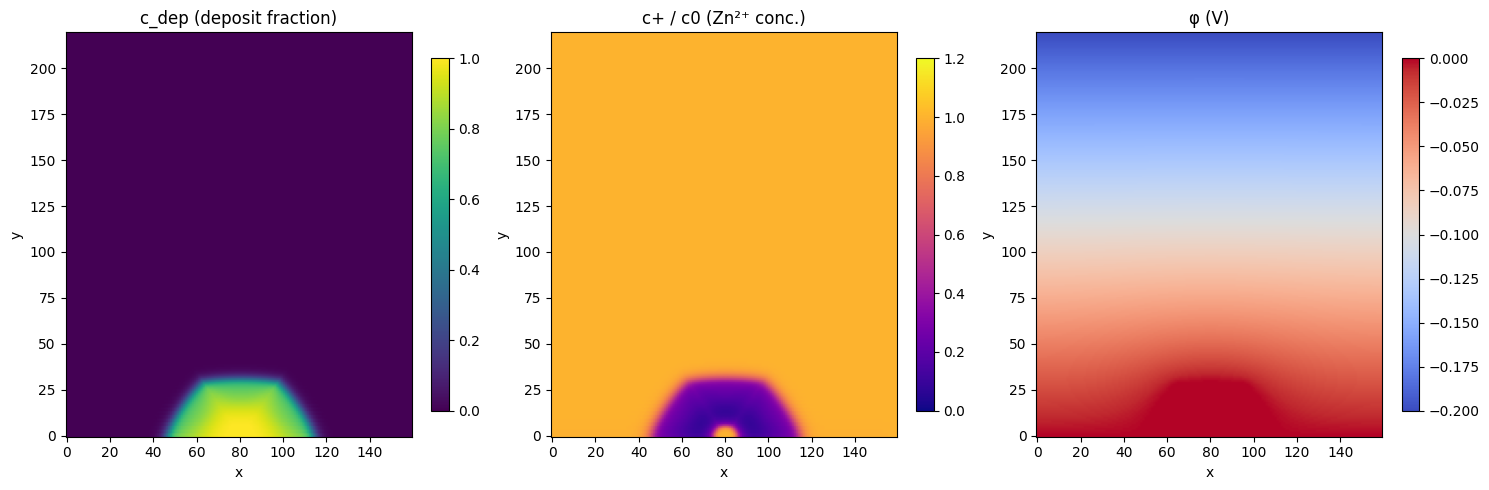

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
panels = [
    (result['c'],   'c_dep (deposit fraction)', (0, 1),    'viridis'),
    (result['cp'],  'c+ / c0 (Zn²⁺ conc.)',     (0, 1.2),  'plasma'),
    (result['phi'], 'φ (V)',                    (-0.2, 0), 'coolwarm'),
]
for a, (f, lab, vm, cm) in zip(ax, panels):
    im = a.imshow(f, origin='lower', aspect='auto', cmap=cm, vmin=vm[0], vmax=vm[1])
    a.set_title(lab)
    a.set_xlabel('x'); a.set_ylabel('y')
    plt.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout()
plt.show()

## Time evolution of the deposit

Snapshots show progressive growth and the boundary layer building up — analog of paper Fig. 2 (a1–a4) and (b1–b4).

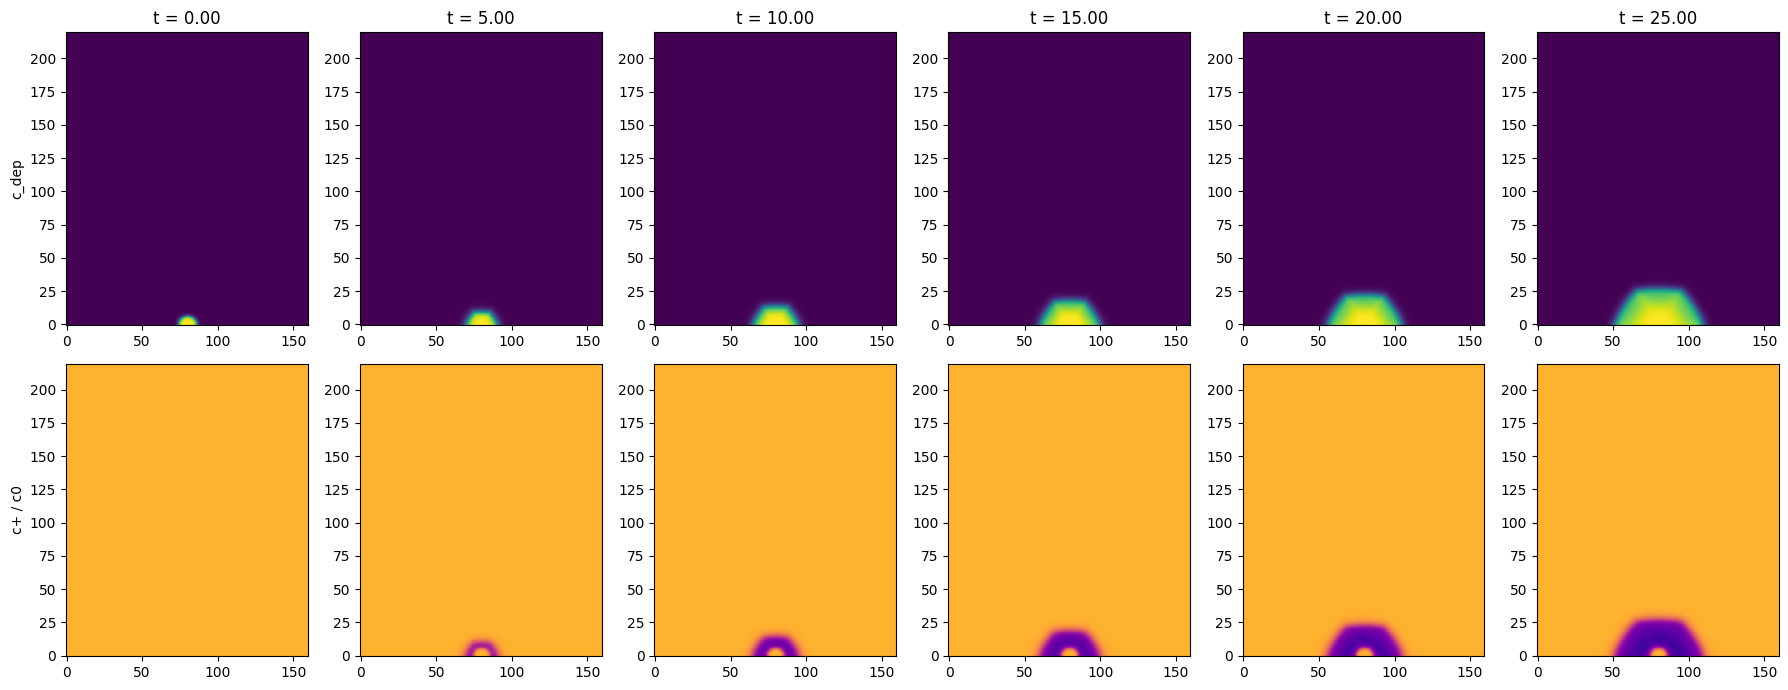

In [5]:
frames = result['frames']
n = len(frames)
fig, ax = plt.subplots(2, n, figsize=(3 * n, 7))
for i, (t, c, cp, phi) in enumerate(frames):
    ax[0, i].imshow(c,  origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=1)
    ax[0, i].set_title(f't = {t:.2f}')
    ax[1, i].imshow(cp, origin='lower', aspect='auto', cmap='plasma',  vmin=0, vmax=1.2)
ax[0, 0].set_ylabel('c_dep')
ax[1, 0].set_ylabel('c+ / c0')
plt.tight_layout()
plt.show()

## Tip height vs time (paper Fig. 2f analogue)

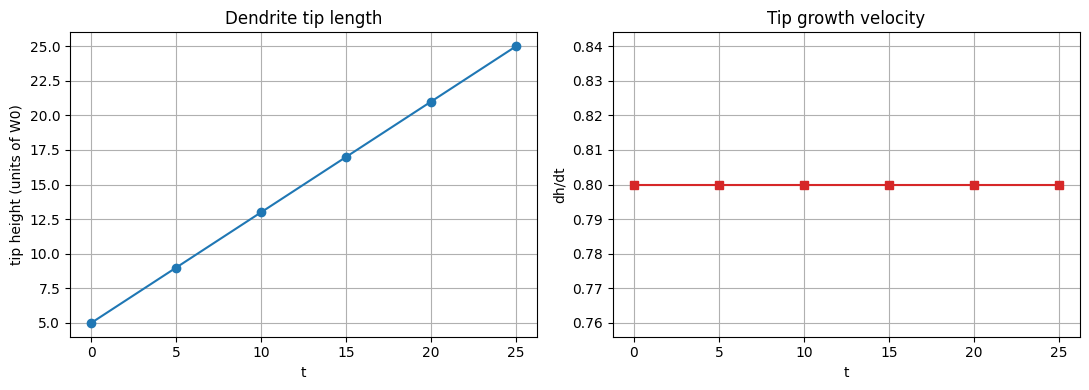

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(result['tip_t'], result['tip_len'], 'o-')
ax[0].set_xlabel('t'); ax[0].set_ylabel('tip height (units of W0)')
ax[0].set_title('Dendrite tip length')
ax[0].grid(True)
# growth velocity = d(tip_len)/dt
v = np.gradient(result['tip_len'], result['tip_t'])
ax[1].plot(result['tip_t'], v, 's-', color='C3')
ax[1].set_xlabel('t'); ax[1].set_ylabel('dh/dt')
ax[1].set_title('Tip growth velocity')
ax[1].grid(True)
plt.tight_layout(); plt.show()

## Parameter sweep — effect of `k_dep` (exchange-current density proxy)

Paper Fig. 3: increasing $i_0$ → faster growth, thicker main branch, more developed sidebranches. Here `k_dep` plays the role of $i_0$.

**Note**: this sweep runs 3 simulations; ~2-3 min total.

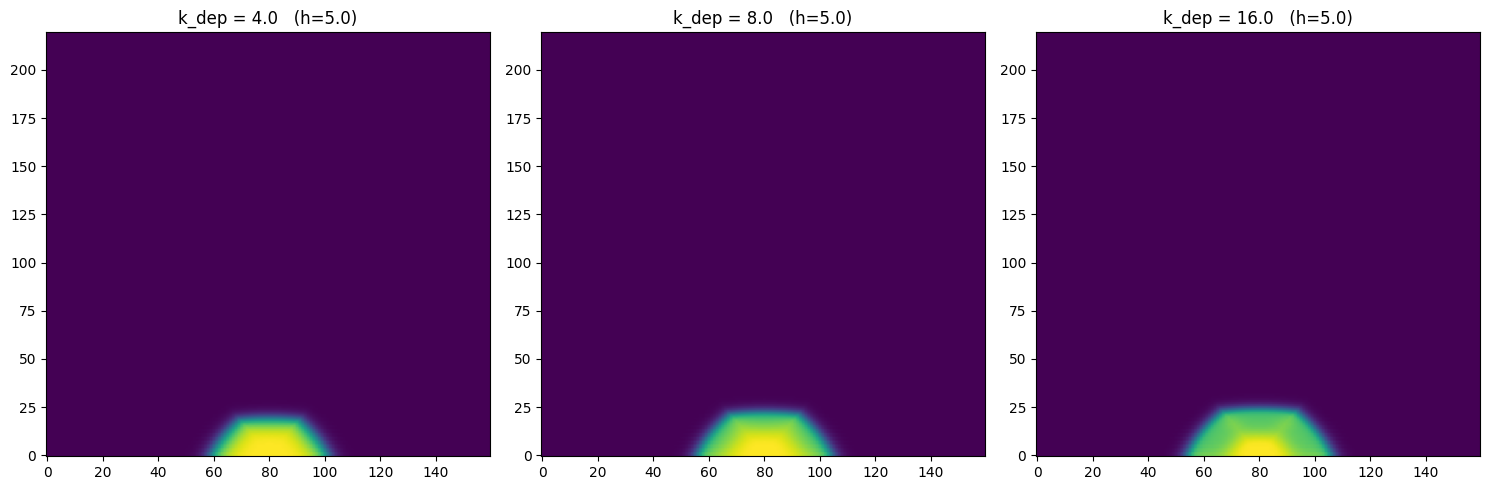

In [7]:
sweep_p = {**params, 'steps': 4000, 'record_every': 4000, 'verbose': False}
k_vals = [4.0, 8.0, 16.0]
outs = [run(**{**sweep_p, 'k_dep': k}) for k in k_vals]
fig, ax = plt.subplots(1, len(k_vals), figsize=(5 * len(k_vals), 5))
for a, k, o in zip(ax, k_vals, outs):
    a.imshow(o['c'], origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=1)
    a.set_title(f'k_dep = {k}   (h={o["tip_len"][-1]:.1f})')
plt.tight_layout(); plt.show()

## Next steps

1. **Add electrolyte flow (LBM)** — Eq. 5-9 of paper. Lattice-Bhatnagar-Gross-Krook D2Q9 with diffuse-interface drag force. Enables paper Fig. 5-6 (forced-flow effects on dendrite tilt and dendrite-free patterns).
2. **Polycrystalline competitive growth** (paper Fig. 7) — multiple seeds with random `theta_j`, integer grain-index field.
3. **Web tool** — wrap `run()` in a small Flask/Gradio interface (sliders for `k_dep`, `Ds`, `E_theta`, `u`) that streams snapshots back to the browser.
4. **Performance** — port `fd_core` hot loop to Numba `@njit` or CuPy for GPU; current pure-NumPy is ~30s/6000 steps on this grid.
5. **Optional ML surrogate** — once the FD solver is producing ground-truth runs, train a neural operator (FNO/DeepONet) on (params → final fields) for interactive web speed.